# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [255]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [256]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [198]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [199]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [200]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [201]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [202]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [203]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [204]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [205]:
# cantidad de nulos para users
print('Cantidad Nulos')
print(users.isna().sum())
print()
print('Proporcion Nulos')
print(users.isna().mean())

Cantidad Nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporcion Nulos
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [206]:
# cantidad de nulos para usage
print('Cantidad de Nulos')
print(usage.isna().sum())
print()
print('Proporcion de Nulos')
print(usage.isna().mean())

Cantidad de Nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporcion de Nulos
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint: 
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- R: Hay valores nulos en date, duration y length, en proporciones de , 0.1%  55% y 44%
- Indica qué harías: ¿imputar, eliminar, ignorar?
- R: **date** se puede dejar como nulo ya que tiene muy pocos valores, no cambiaría mucho,
- **duration** se ignoraria ya que presenta más de la mitad de los datos faltantes
- **length** se investigaria si imputarlo o dejar como nulo 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [207]:
# explorar columnas numéricas de users
print(users.describe())

print(users.median())


            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000
user_id    11999.5
age           47.0
dtype: float64


- La columna `user_id` se encuentran valores identicos entre la mediana y promedio
- La columna `age` ... si varia el valor de la mediana y el promedi, se encuentran valores extraños como edad -999

In [208]:
# explorar columnas numéricas de usage
print(usage[['id', 'user_id']].describe())
print(usage[['id', 'user_id']].median())

                id       user_id
count  40000.00000  40000.000000
mean   20000.50000  12002.405975
std    11547.14972   1157.279564
min        1.00000  10000.000000
25%    10000.75000  10996.000000
50%    20000.50000  12013.000000
75%    30000.25000  13005.000000
max    40000.00000  13999.000000
id         20000.5
user_id    12013.0
dtype: float64


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas `id` y `user_id` presentan valores muy similares entre la media y el promedio

In [209]:
# explorar columnas categóricas de users

columnas_user = ['city', 'plan']
users[columnas_user].info()
print()


print(users[columnas_user].value_counts())
print(users[columnas_user].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   city    3531 non-null   object
 1   plan    4000 non-null   object
dtypes: object(2)
memory usage: 62.6+ KB

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64
city      plan   
Bogotá    Basico     0.147833
CDMX      Basico     0.134240
Medellín  Basico     0.112716
GDL       Basico     0.084395
Bogotá    Premium    0.080997
MTY       Basico     0.077882
Cali      Basico     0.074200
CDMX      Premium    0.072501
Medellín  Premium    0.061739
Cali      Premium    0.045879
GDL      

- La columna `city` hay 7 ciudades, en esa ciudades hay aproximadamente el 12% de valores faltantes 
- La columna `plan` solo hay 2 planes y no hay valores faltantes

In [210]:
# explorar columna categórica de usage
print(usage['type'].describe())

print()
print(usage['type'].value_counts())
 # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

text    22092
call    17908
Name: type, dtype: int64


- La columna `type` unicamente cuenta con 2 categorias y cuenta con una distribución relativamente balanceada aunque hay superioridad de text


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Se encontraron valores como -999 para la edad minima de usuario, también se encontró un valor extraño "?" en city
- ¿Qué acción tomarías?
- Se puede corregir imputando con la mediana ya que los valores extremos disminuyen el promedio, y en cuanto al ? se pueden sustituir por NA

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [211]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [212]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')# completa el código

In [213]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, hay 4 años en total, en ellos hay una cantidad similar de registros en cada uno, el año 2026 es un error ya que unicamente se estaría trabajando con datos hasta el 2024

In [214]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

En `date`, ... unicamente esta el año 2024 con la totalidad de los datos.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- R: el año 2026 no se tomaba en cuenta ya que la información es hasta el 2024
- ¿Qué harías con ellas?
- R: se revisan y, si no pueden corregirse, se excluyen del análisis o se convierten en valores nulos

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [215]:
# Reemplazar -999 por la mediana de age
age_mediana = 47
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [216]:
# Reemplazar ? por NA en city
users['city'] = users['city'].str.strip()
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print(users['city'].value_counts())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [217]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT   
# Verificar cambios
print(users['reg_date'].value_counts())

2024-06-27 06:08:22.325581392    1
2023-03-31 06:21:20.120030008    1
2024-06-20 09:50:54.463615904    1
2022-05-22 00:23:45.956489122    1
2022-04-23 06:22:24.936234060    1
                                ..
2022-07-29 04:44:06.661665416    1
2022-02-22 00:36:43.750937734    1
2022-10-31 09:22:49.242310580    1
2022-09-24 16:46:48.702175544    1
2022-03-28 12:38:20.975243811    1
Name: reg_date, Length: 3960, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [218]:

# Verificación MAR en usage (Missing At Random) para duration

usage['duration'].isna().groupby(usage['type']).mean()


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [219]:
# Verificación MAR en usage (Missing At Random) para length

usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length` 
Los valores son correctos, no son MAR, no se imputara ni eliminaran valores, ya que en duration unicamente se llenan valores de llamada (por eso text tiene la totalidad de valores faltantes) y length es exclusivo de texto (por eso call tiene totalidad de nulos)

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [220]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text' : 'sum', 'is_call': 'sum', 'duration':'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [221]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes', 'is_call':'cant_llamadas', 'duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [222]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [223]:
# Resumen estadístico de las columnas numéricas
user_profile[['cant_mensajes','cant_llamadas', 'cant_minutos_llamada']].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [224]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

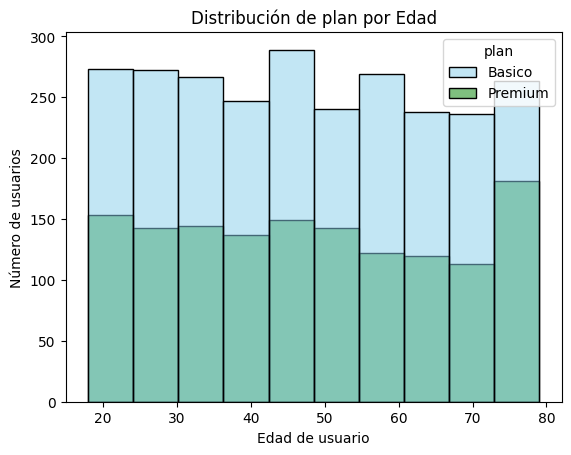

In [225]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=10, hue='plan', palette=['skyblue','green'])
plt.xlabel('Edad de usuario')
plt.ylabel('Número de usuarios')
plt.title('Distribución de plan por Edad')
plt.show()

💡Insights: 
- Distribución uniforme entre todo grupo de edades, aunque hay ligera superioridad entre usuarios de 42 a 50 años, no se nota diferencia entre planes

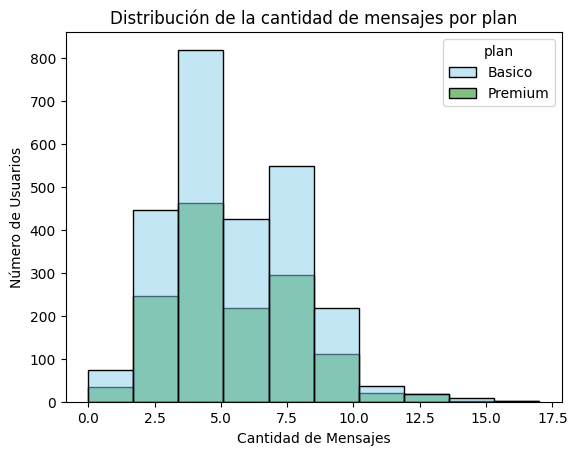

In [226]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, hue='plan', palette=['skyblue','green'])
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Número de Usuarios')
plt.title('Distribución de la cantidad de mensajes por plan')
plt.show()

💡Insights: 
- Hay una gran predominancia de usuarios que mandan entre 3 y 5 mensajes en ambos planes, no se nota diferencia real entre planes, hay poca cantidad de usuarios que mandan más de 12 mensajes lo que indica que hay rigth skewd


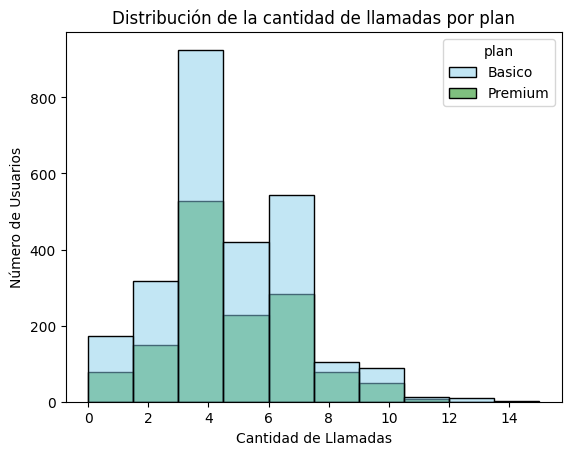

In [227]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, hue='plan', palette=['skyblue','green'])
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Número de Usuarios')
plt.title('Distribución de la cantidad de llamadas por plan')
plt.show()

💡Insights: 
- La distribución de llamadas se concentra principalmente entre 3 y 6 llamadas, con un pico alrededor de 3–4 llamadas por usuario, no se nota una diferencia muy marcada entre distintos planes de usuarios, hay una cola a paratir de 10 llamadas, lo que indica un rigth skewd

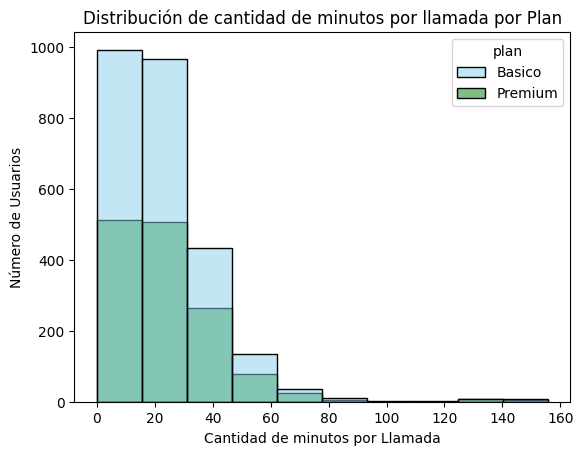

In [228]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, hue='plan', palette=['skyblue', 'green'])
plt.xlabel('Cantidad de minutos por Llamada')
plt.ylabel('Número de Usuarios')
plt.title('Distribución de cantidad de minutos por llamada por Plan')
plt.show()

💡Insights: La mayoría de las llamadas se concentra entre 0 y 30 minutos, lo que indica un uso principalmente corto a moderado, no hay una diferencia demasiado marcada entre planes, a partir de 60 minutos se genera una cola hacia la derecha lo que indica rigth skewd, hay valores muy extremos como 150mins, lo que puede indicar posibles outliers
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

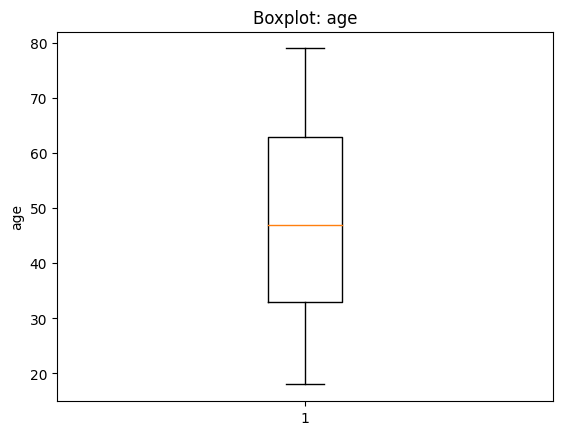

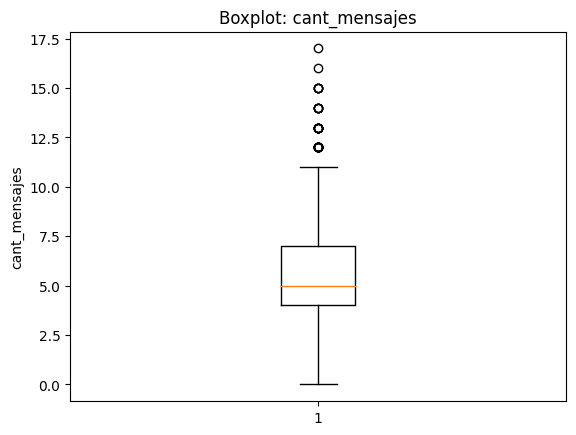

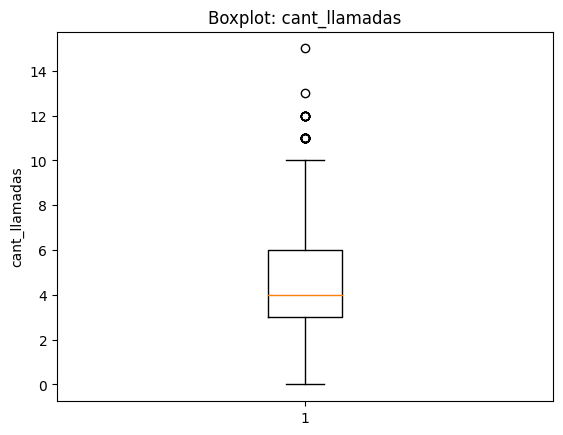

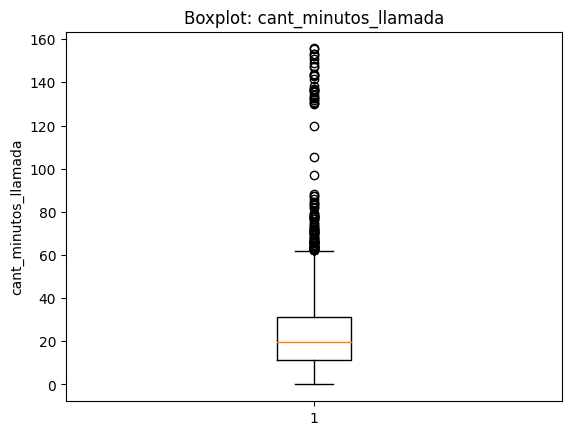

In [236]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.boxplot(user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers) No presenta outliers
- cant_mensajes: Presenta outliers
- cant_llamadas: Presenta outliers
- cant_minutos_llamada: Presenta outliers

In [254]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(col,'Q1:', Q1,'Q3:', Q3, 'IQR:', IQR, 'limite_superior', limite_superior)
    





cant_mensajes Q1: 4.0 Q3: 7.0 IQR: 3.0 limite_superior 11.5
cant_llamadas Q1: 3.0 Q3: 6.0 IQR: 3.0 limite_superior 10.5
cant_minutos_llamada Q1: 11.12 Q3: 31.415 IQR: 20.295 limite_superior 61.8575


In [253]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Se deben mantener los outliers Aunque existen valores por encima del límite superior, estos representan usuarios con mayor actividad real y no errores. Eliminarlos podría sesgar el análisis del comportamiento de usuarios intensivos. No se encuentran valores irreales o absurdos.
- cant_llamadas: mantener o no outliers, porqué? Los valores altos reflejan usuarios que realizan más llamadas de lo habitual, lo cual es relevante para el análisis del uso del servicio. No hay evidencia de datos erróneos.
- cant_minutos_llamada: mantener o no outliers, porqué? Existe una cola larga hacia la derecha con valores altos, pero estos representan usuarios intensivos en consumo de minutos. Son clave para segmentación y análisis de negocio, por lo que no deben eliminarse, aunque deben analizarse con cuidado ya que se presentan algunos valores muy extremos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [267]:
# Crear columna grupo_uso
def grupo_uso(llamadas, mensajes):

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(lambda row: grupo_uso(row['cant_llamadas'], row['cant_mensajes']), axis=1)


In [268]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [271]:
# Crear columna grupo_edad
def grupo_edad(age):
    if age < 30:
        return('Joven')
    elif age < 60:
        return('Adulto')
    else:
        return('Adulto Mayor')

user_profile['grupo_edad'] = user_profile.apply(lambda row: grupo_edad(row['age']), axis=1)

In [272]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

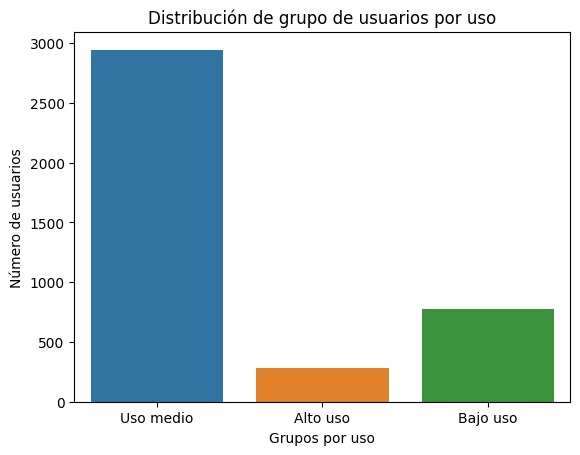

In [276]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de grupo de usuarios por uso')
plt.xlabel('Grupos por uso')
plt.ylabel('Número de usuarios')
plt.show()

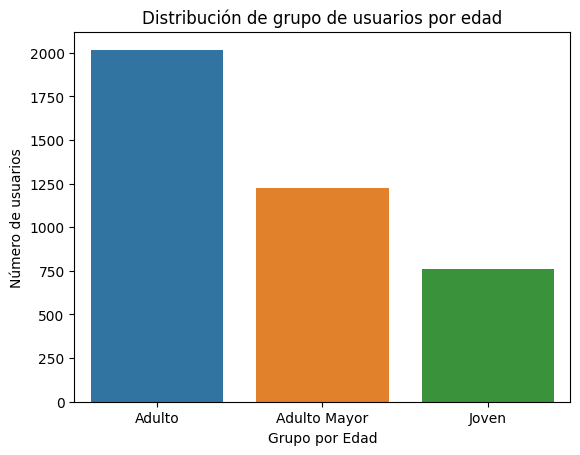

In [277]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de grupo de usuarios por edad')
plt.xlabel('Grupo por Edad')
plt.ylabel('Número de usuarios')
plt.show()


---

## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- Principalmente habia 2 problemas, valores irreales como -999 en edad y varias ciudades sin clasificar marcadas como '?' que representaba el 2.6% total de los datos 

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- Los clientes adultos de entre 30 y 59 años son los que presentan mayoría, sin embargo la edad y el nivel de uso no tiene una relación comprobable.
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- Principalemnte los usuarios con un Alto uso, ya que son los que generan mayor ganancia por uso de servicio
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- En outliers están las llamadas extremas de 155 minutos aproximadamente, estos casos representan comportamientos valiosos de usuarios y no deben de eliminarse.
- Usuarios con mas llamadas y mensajes de lo normal pero ese segmento no tiene valores absurdos, pueden ser perfectamente de usuarios con un alto uso de servicio


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
- Segmentación basada en el comportamiento, se podrá utilizar esta informacion para identificar clientes con potencial de mejorar su servicio
- Diseñar planes para usuarios que utilicen muchos minutos, se podría crear un plan exlusivo con mayor cantidad de minutos.
- Monitoreo de usuarios de alto consumo para detectar patrones y necesidades especificas y asi poder crear planes en el futuro mas enfocado a estos usuarios

✍️ **Escribe aquí tu análisis ejecutivo:**



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Presencia de valores irreales (-999) para edad.
- Presencia de simbolos extraños (?) en ciudad.


🔍 **Segmentos por Edad**
- La distribución de edad es similar entre usuarios de plan Básico y Premium.
- La edad no es un factor determinante en el comportamiento de uso ni en la elección de plan.


📊 **Segmentos por Nivel de Uso**
- La mayoria de los usuarios se concentra en uso bajo y medio.
- Hay un grupo de usuario de uso alto que representan una cola larga a la derecha.


➡️ Esto sugiere que el comportamiento de uso no está segmentado por edad sino por la cantidad de consumo, donde los usuarios con un mayor uso representan una gran oportunidad.

💡 **Recomendaciones**
- Diseñar planes dirigidos a usuarios con un alto uso con beneficios que se enfoquen a un mayor consumo.
- Implementar planes para convertir usuarios de uso medio hacia planes premium ya que es la gran mayoria de usuarios. 


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`